# QCOM EGARCH

EGARCH(1,1) with Student-t shocks on QCOM daily log returns (%).

notes:
- Forecasts are one day ahead for each session from 2024-08-23 to 2026-08-31; the model is refit every day on all returns up to the day before.
- Forecasts are volatility in daily %, scored against squared returns.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from arch import arch_model

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10,
})

## 1. Returns

In [2]:
CSV_PATH = Path("data/qcom_returns.csv")  # group file: date, log_return_pct (split/dividend-adjusted closes)

def load_qcom_returns(csv_path=CSV_PATH):
    """Daily log returns in percent, r_t = 100 * ln(C_t / C_{t-1}), indexed by session date."""
    df = pd.read_csv(csv_path, parse_dates=["date"], index_col="date")
    r = df["log_return_pct"].dropna().sort_index()
    if r.index.duplicated().any():
        raise ValueError(f"{csv_path} has duplicate dates")
    return r

r = load_qcom_returns()
print(f"n = {len(r)} daily log returns (%), {r.index[0].date()} to {r.index[-1].date()}")

n = 5008 daily log returns (%), 2006-10-03 to 2026-08-31


## 2. Training fit

In [3]:
MODEL_NAME = "EGARCH(1,1)-t"
FORECAST_START = "2024-08-23"  # first session in QCOM_option


def _fit(returns, starting_values=None):
    am = arch_model(returns, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
    res = am.fit(disp="off", starting_values=starting_values)
    if res.convergence_flag != 0:
        res = am.fit(disp="off", options={"maxiter": 1000})
    if res.convergence_flag != 0:
        raise RuntimeError(f"EGARCH failed to converge on data ending {returns.index[-1].date()} "
                           f"(flag {res.convergence_flag})")
    return res


def _forecast_variance(res, horizon):
    if horizon == 1:
        fc = res.forecast(horizon=1, reindex=False)
    else:  # arch has no analytic multi-step EGARCH forecast
        fc = res.forecast(horizon=horizon, method="simulation", simulations=2000,
                          random_state=np.random.default_rng(0), reindex=False)
    return float(fc.variance.iloc[-1, horizon - 1])


def fit_egarch(returns, horizon=1, forecast_start=FORECAST_START, forecast_end=None):
    """Training fit on returns before `forecast_start`, then rolling out-of-sample forecasts.

    For each target date t from `forecast_start` to `forecast_end`, refit on all returns up to
    t - horizon (expanding window) and return the square root of the forecast variance.
    Returns the group's shared dict: model, params, loglik, aic, bic, forecast_vol (daily %,
    indexed by the date forecast), horizon, train_end (plus tvalues).
    """
    if horizon < 1:
        raise ValueError("horizon must be >= 1")
    returns = returns.dropna()
    idx = returns.index
    train = returns[idx < pd.Timestamp(forecast_start)]
    res_train = _fit(train)

    targets = idx[(idx >= pd.Timestamp(forecast_start))
                  & (idx <= pd.Timestamp(forecast_end or idx[-1]))]
    vols, params = [], res_train.params
    for target in targets:
        fit_end = idx.get_loc(target) - horizon + 1  # data up to t - horizon, exclusive slice end
        res = _fit(returns.iloc[:fit_end], starting_values=params)
        params = res.params
        vols.append(np.sqrt(_forecast_variance(res, horizon)))

    forecast_vol = pd.Series(vols, index=targets, name="forecast_vol_pct")
    forecast_vol.index.name = "date"
    return {
        "model": MODEL_NAME,
        "params": res_train.params,
        "tvalues": res_train.tvalues,
        "loglik": float(res_train.loglikelihood),
        "aic": float(res_train.aic),
        "bic": float(res_train.bic),
        "forecast_vol": forecast_vol,
        "horizon": horizon,
        "train_end": train.index[-1],
    }

In [4]:
out = fit_egarch(r, horizon=1)

params = pd.DataFrame({"estimate": out["params"], "t-stat": out["tvalues"]}).round(4)
fit_stats = pd.Series({"log-likelihood": out["loglik"], "AIC": out["aic"], "BIC": out["bic"]}).round(1)
print(f"{out['model']}, training sample {r.index[0].date()} to {out['train_end'].date()}")
display(params)
fit_stats.to_frame("training fit")

EGARCH(1,1)-t, training sample 2006-10-03 to 2024-08-22


,estimate,t-stat
mu,0.0553,2.6078
omega,0.0341,3.2068
alpha[1],0.1621,6.0387
gamma[1],-0.0491,-4.1299
beta[1],0.9845,168.1001
nu,3.9974,15.3266


,training fit
log-likelihood,-8987.3
AIC,17986.5
BIC,18025.0


## 3. Rolling one-day forecasts

In [5]:
def evaluate_forecasts(forecast_vol, returns):
    """MSE of forecast variance vs squared returns (the realised-variance proxy), on matching dates."""
    df = pd.concat({"vol": forecast_vol, "r": returns}, axis=1, join="inner").dropna()
    var_f = df["vol"] ** 2
    r2 = df["r"] ** 2
    return {"mse": float(np.mean((var_f - r2) ** 2)), "n": int(len(df))}

fv = out["forecast_vol"]
print(f"{fv.index[0].date()} to {fv.index[-1].date()} (daily %)")
display(pd.concat([fv.head(3), fv.tail(3)]).round(3).to_frame())
scores = evaluate_forecasts(fv, r)
pd.Series({"MSE": round(scores["mse"], 1), "n": scores["n"]}, dtype=object).to_frame("vs squared returns")

2024-08-23 to 2026-08-31 (daily %)


,forecast_vol_pct
date,
2024-08-23,3.226
2024-08-26,3.161
2024-08-27,3.207
2026-08-27,2.438
2026-08-28,2.314
2026-08-31,2.204


,vs squared returns
MSE,436.4
n,506


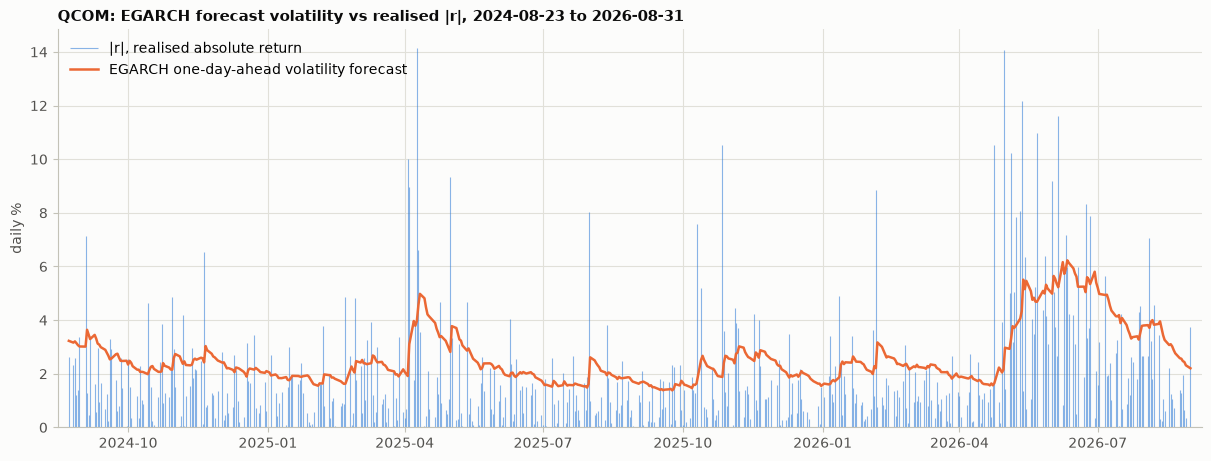

In [6]:
abs_r = r.loc[fv.index].abs()

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
ax.vlines(abs_r.index, 0, abs_r.values, color=BLUE, lw=0.8, alpha=0.55, label="|r|, realised absolute return")
ax.plot(fv.index, fv.values, color=ORANGE, lw=1.8, label="EGARCH one-day-ahead volatility forecast")
ax.set_ylabel("daily %")
ax.set_title(f"QCOM: EGARCH forecast volatility vs realised |r|, {fv.index[0]:%Y-%m-%d} to {fv.index[-1]:%Y-%m-%d}", loc="left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_ylim(bottom=0)
ax.margins(x=0.01)
ax.legend(loc="upper left", frameon=False)
plt.show()